# Import Libraries

In [39]:
#data manipulation and visualisation libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

#import interactive library
from ipywidgets import interact

#balancing the target variable
from imblearn.over_sampling import RandomOverSampler

#variable scaling libraries
from sklearn.preprocessing import StandardScaler

#sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

#feature selection libraries
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

#evaluation metrics
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

#import hyperparameter tuning library
from sklearn.model_selection import GridSearchCV

#other libraries
import math
from collections import Counter

In [40]:
# !pip3 install numpy
! pip3 install pandas
! pip3 install matplotlib
! pip3 install seaborn
! pip3 install ipywidgets
! pip3 install scikit-learn 
!pip3 install imblearn



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
data = pd.read_csv('data/waterQuality1.csv')

In [42]:
data.head()

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1


In [43]:
data.tail()

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
7994,0.05,7.78,0.00,1.95,0.04,0.10,0.03,0.03,1.37,0.0,...,0.197,14.29,1.0,0.005,3.57,2.13,0.09,0.06,0.03,1
7995,0.05,24.22,0.02,0.59,0.01,0.45,0.02,0.02,1.48,0.0,...,0.031,10.27,1.0,0.001,1.48,1.11,0.09,0.10,0.08,1
7996,0.09,6.85,0.00,0.61,0.03,0.05,0.05,0.02,0.91,0.0,...,0.182,15.92,1.0,0.000,1.35,4.84,0.00,0.04,0.05,1
7997,0.01,10,0.01,2.00,0.00,2.00,0.00,0.09,0.00,0.0,...,0.000,0.00,0.0,0.000,0.00,0.00,0.00,0.00,0.00,1
7998,0.04,6.85,0.01,0.70,0.03,0.05,0.01,0.03,1.00,0.0,...,0.182,15.92,1.0,0.000,1.35,4.84,0.00,0.04,0.05,1


In [44]:
data.shape

(7999, 21)

In [45]:
data.columns

Index(['aluminium', 'ammonia', 'arsenic', 'barium', 'cadmium', 'chloramine',
       'chromium', 'copper', 'flouride', 'bacteria', 'viruses', 'lead',
       'nitrates', 'nitrites', 'mercury', 'perchlorate', 'radium', 'selenium',
       'silver', 'uranium', 'is_safe'],
      dtype='str')

In [46]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7999 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7999 non-null   float64
 1   ammonia      7999 non-null   str    
 2   arsenic      7999 non-null   float64
 3   barium       7999 non-null   float64
 4   cadmium      7999 non-null   float64
 5   chloramine   7999 non-null   float64
 6   chromium     7999 non-null   float64
 7   copper       7999 non-null   float64
 8   flouride     7999 non-null   float64
 9   bacteria     7999 non-null   float64
 10  viruses      7999 non-null   float64
 11  lead         7999 non-null   float64
 12  nitrates     7999 non-null   float64
 13  nitrites     7999 non-null   float64
 14  mercury      7999 non-null   float64
 15  perchlorate  7999 non-null   float64
 16  radium       7999 non-null   float64
 17  selenium     7999 non-null   float64
 18  silver       7999 non-null   float64
 19  uranium      7999

In [47]:
#drop missing values
data['ammonia'].value_counts()['#NUM!']
data = data[data['ammonia'].str.contains('#NUM!') == False]

In [48]:
data.shape

(7996, 21)

In [49]:
#convert both columns to numeric data type
data['ammonia'] = pd.to_numeric(data['ammonia'])
data['is_safe'] = pd.to_numeric(data['is_safe'])
data

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7994,0.05,7.78,0.00,1.95,0.040,0.10,0.03,0.03,1.37,0.00,...,0.197,14.29,1.00,0.005,3.57,2.13,0.09,0.06,0.03,1
7995,0.05,24.22,0.02,0.59,0.010,0.45,0.02,0.02,1.48,0.00,...,0.031,10.27,1.00,0.001,1.48,1.11,0.09,0.10,0.08,1
7996,0.09,6.85,0.00,0.61,0.030,0.05,0.05,0.02,0.91,0.00,...,0.182,15.92,1.00,0.000,1.35,4.84,0.00,0.04,0.05,1
7997,0.01,10.00,0.01,2.00,0.000,2.00,0.00,0.09,0.00,0.00,...,0.000,0.00,0.00,0.000,0.00,0.00,0.00,0.00,0.00,1


In [50]:
data.info()

<class 'pandas.DataFrame'>
Index: 7996 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7996 non-null   float64
 1   ammonia      7996 non-null   float64
 2   arsenic      7996 non-null   float64
 3   barium       7996 non-null   float64
 4   cadmium      7996 non-null   float64
 5   chloramine   7996 non-null   float64
 6   chromium     7996 non-null   float64
 7   copper       7996 non-null   float64
 8   flouride     7996 non-null   float64
 9   bacteria     7996 non-null   float64
 10  viruses      7996 non-null   float64
 11  lead         7996 non-null   float64
 12  nitrates     7996 non-null   float64
 13  nitrites     7996 non-null   float64
 14  mercury      7996 non-null   float64
 15  perchlorate  7996 non-null   float64
 16  radium       7996 non-null   float64
 17  selenium     7996 non-null   float64
 18  silver       7996 non-null   float64
 19  uranium      7996 non-

In [51]:
data.describe()

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
count,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,...,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000
mean,0.666396,14.278212,0.161477,1.567928,0.042803,2.177589,0.247300,0.805940,0.771646,0.319714,...,0.099431,9.819250,1.329846,0.005193,16.465266,2.920106,0.049684,0.147811,0.044672,0.114057
std,1.265323,8.878930,0.252632,1.216227,0.036049,2.567210,0.270663,0.653595,0.435423,0.329497,...,0.058169,5.541977,0.573271,0.002967,17.688827,2.322805,0.028773,0.143569,0.026906,0.317900
min,0.000000,-0.080000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.040000,6.577500,0.030000,0.560000,0.008000,0.100000,0.050000,0.090000,0.407500,0.000000,...,0.048000,5.000000,1.000000,0.003000,2.170000,0.820000,0.020000,0.040000,0.020000,0.000000
50%,0.070000,14.130000,0.050000,1.190000,0.040000,0.530000,0.090000,0.750000,0.770000,0.220000,...,0.102000,9.930000,1.420000,0.005000,7.745000,2.410000,0.050000,0.080000,0.050000,0.000000
75%,0.280000,22.132500,0.100000,2.482500,0.070000,4.240000,0.440000,1.390000,1.160000,0.610000,...,0.151000,14.610000,1.760000,0.008000,29.487500,4.670000,0.070000,0.240000,0.070000,0.000000
max,5.050000,29.840000,1.050000,4.940000,0.130000,8.680000,0.900000,2.000000,1.500000,1.000000,...,0.200000,19.830000,2.930000,0.010000,60.010000,7.990000,0.100000,0.500000,0.090000,1.000000


In [52]:
data

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7994,0.05,7.78,0.00,1.95,0.040,0.10,0.03,0.03,1.37,0.00,...,0.197,14.29,1.00,0.005,3.57,2.13,0.09,0.06,0.03,1
7995,0.05,24.22,0.02,0.59,0.010,0.45,0.02,0.02,1.48,0.00,...,0.031,10.27,1.00,0.001,1.48,1.11,0.09,0.10,0.08,1
7996,0.09,6.85,0.00,0.61,0.030,0.05,0.05,0.02,0.91,0.00,...,0.182,15.92,1.00,0.000,1.35,4.84,0.00,0.04,0.05,1
7997,0.01,10.00,0.01,2.00,0.000,2.00,0.00,0.09,0.00,0.00,...,0.000,0.00,0.00,0.000,0.00,0.00,0.00,0.00,0.00,1


C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


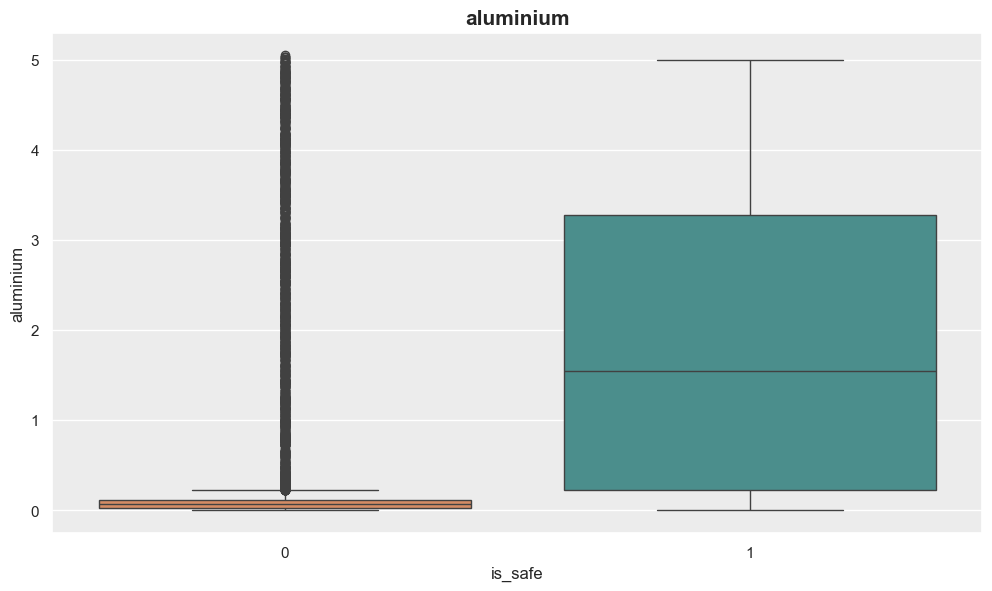

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


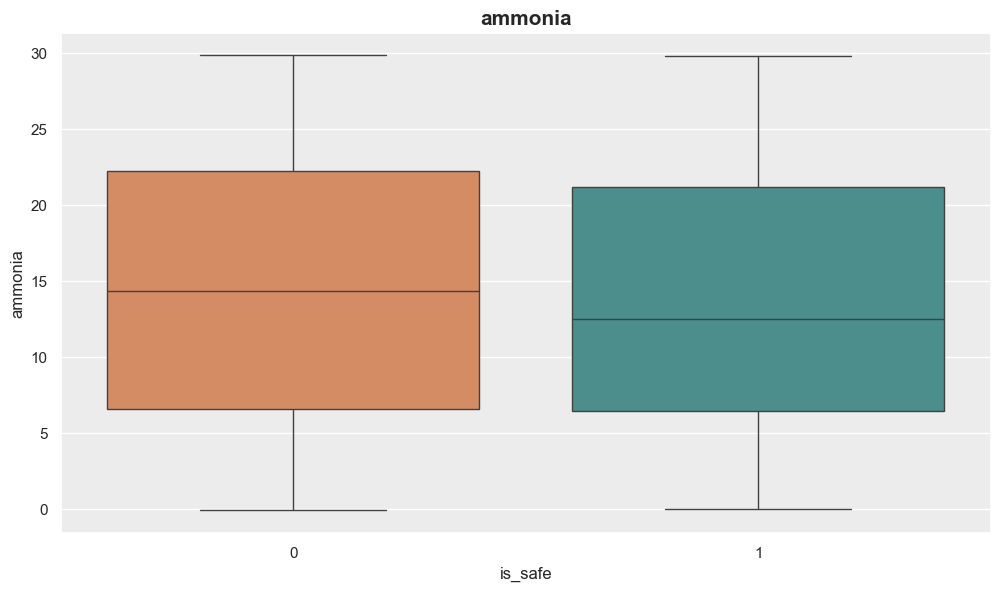

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


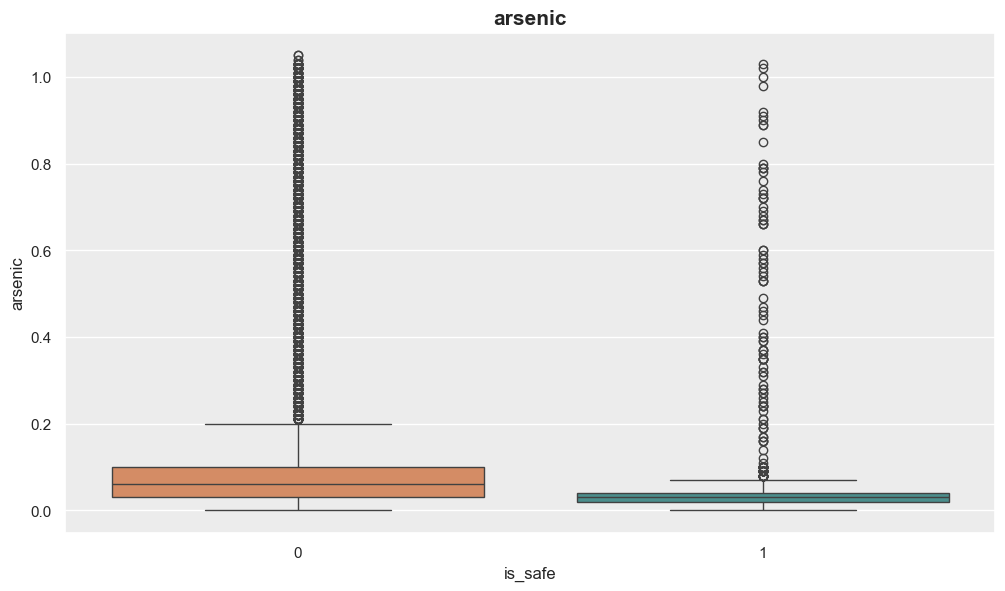

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


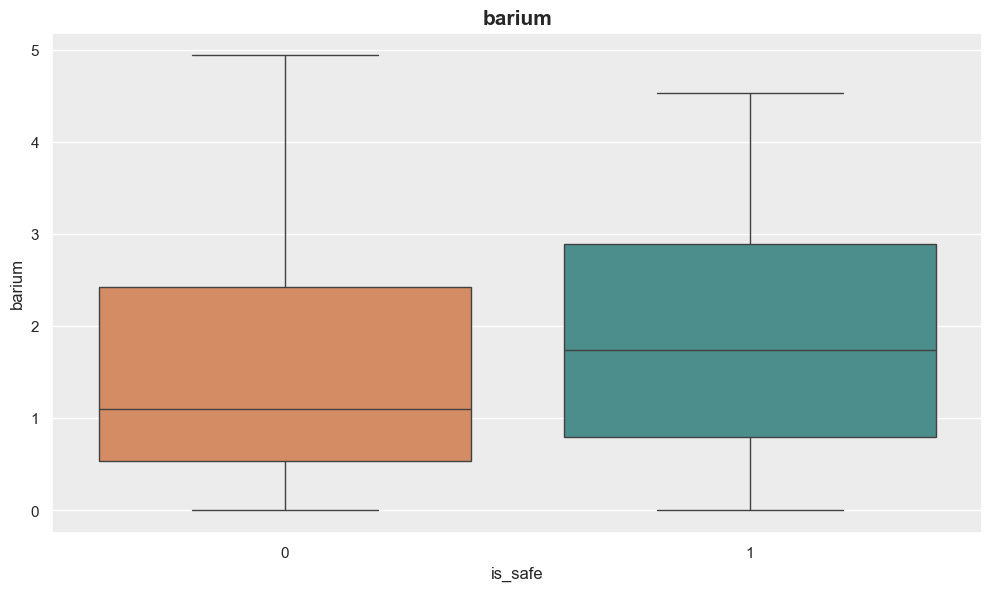

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


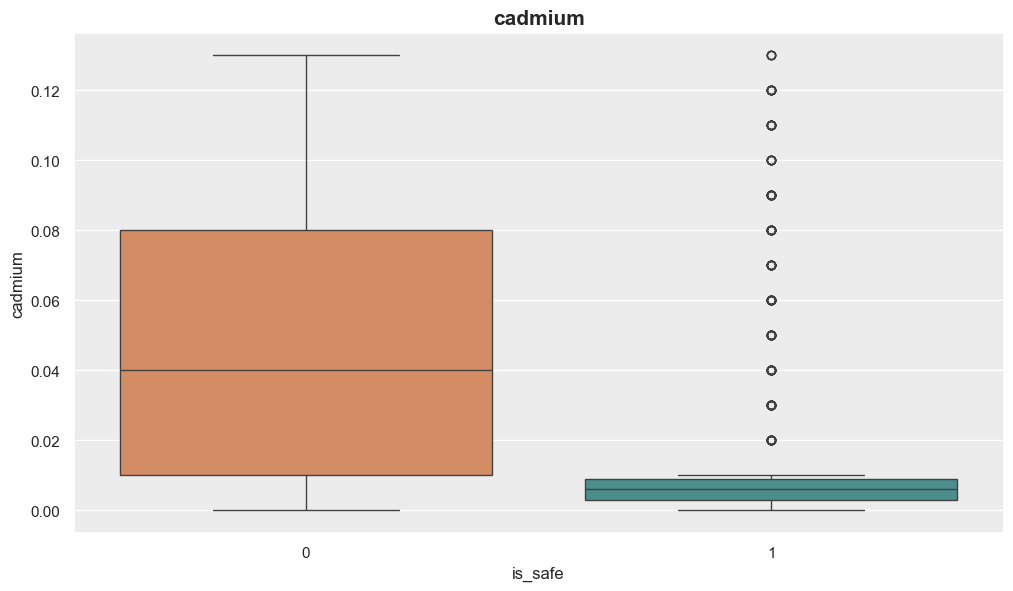

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


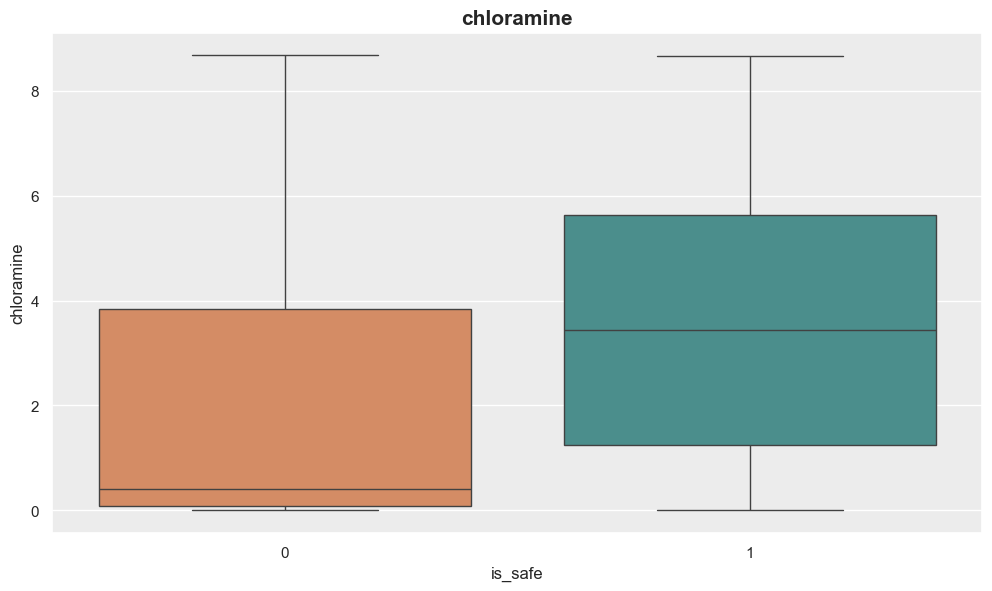

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


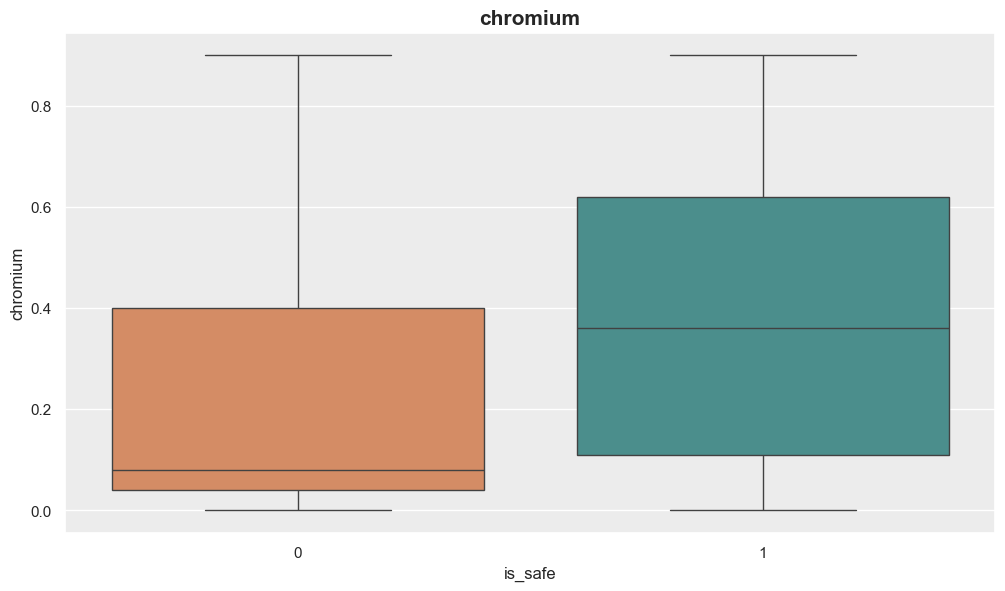

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


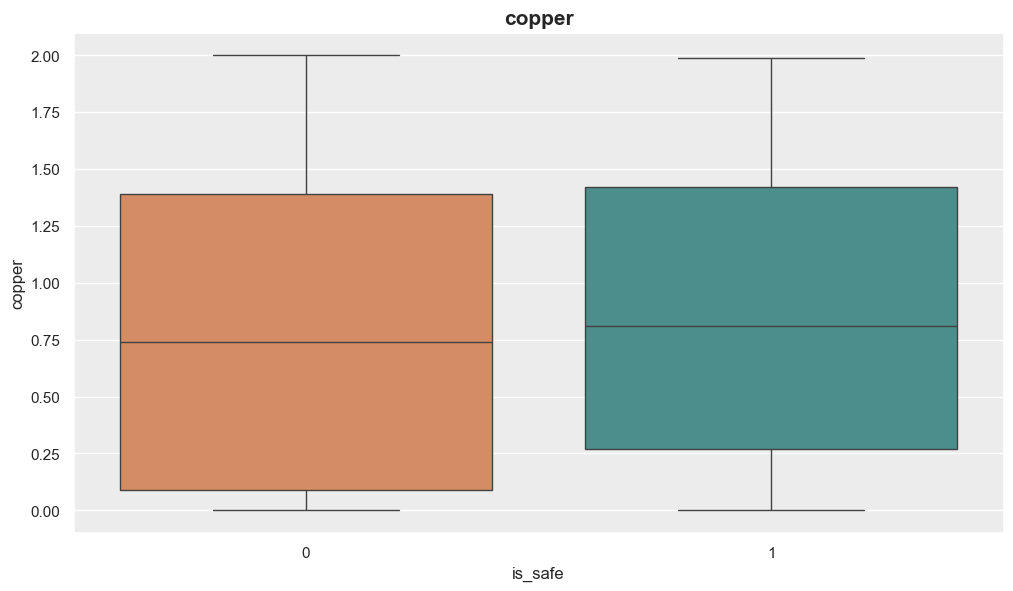

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


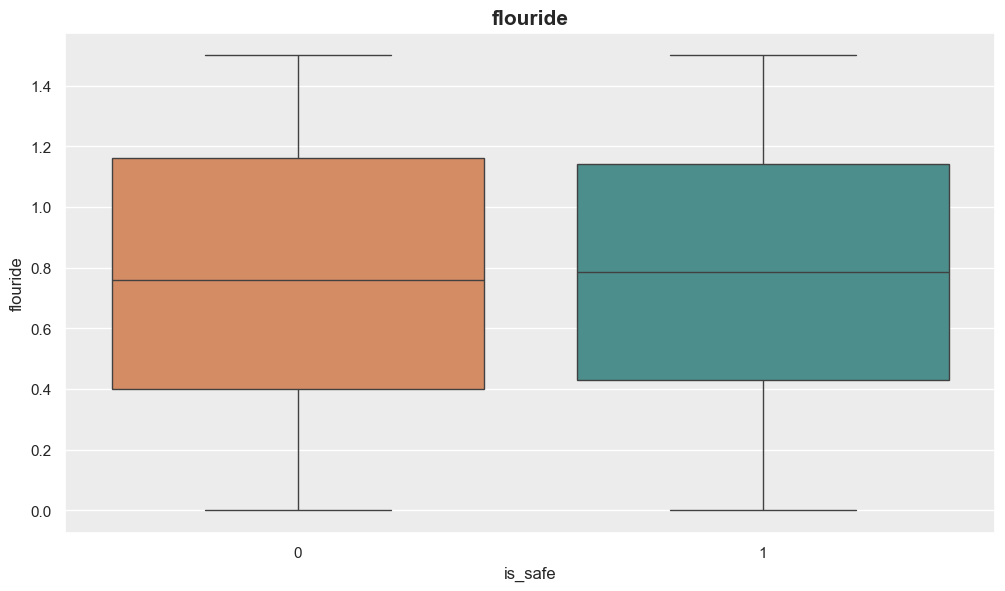

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


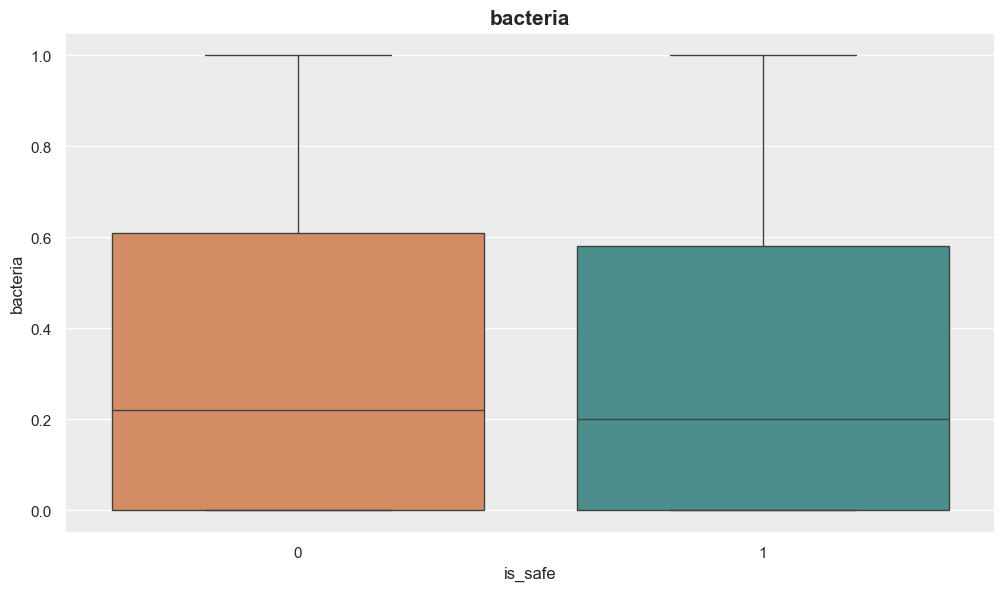

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


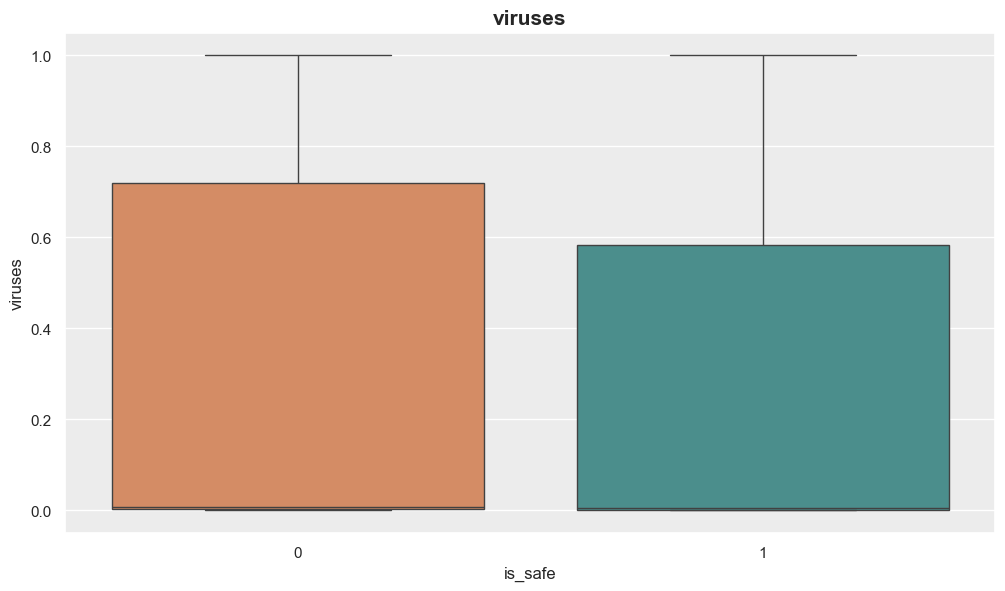

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


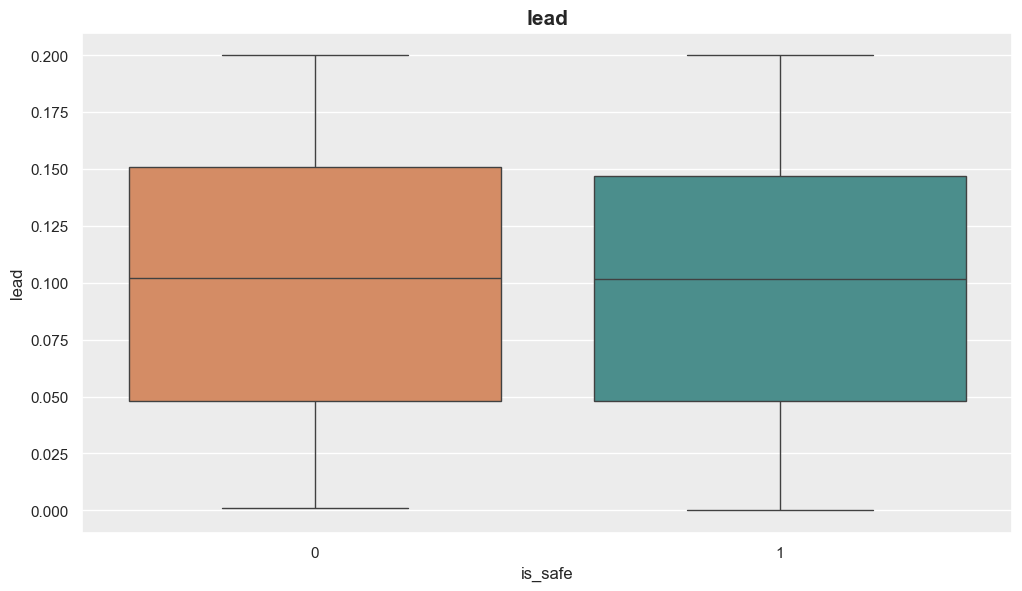

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


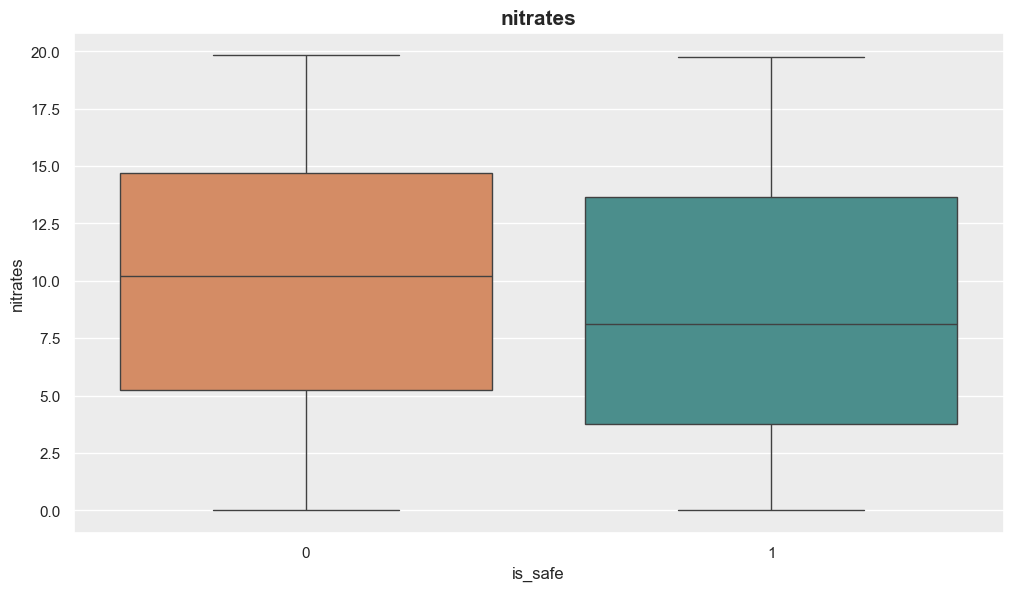

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


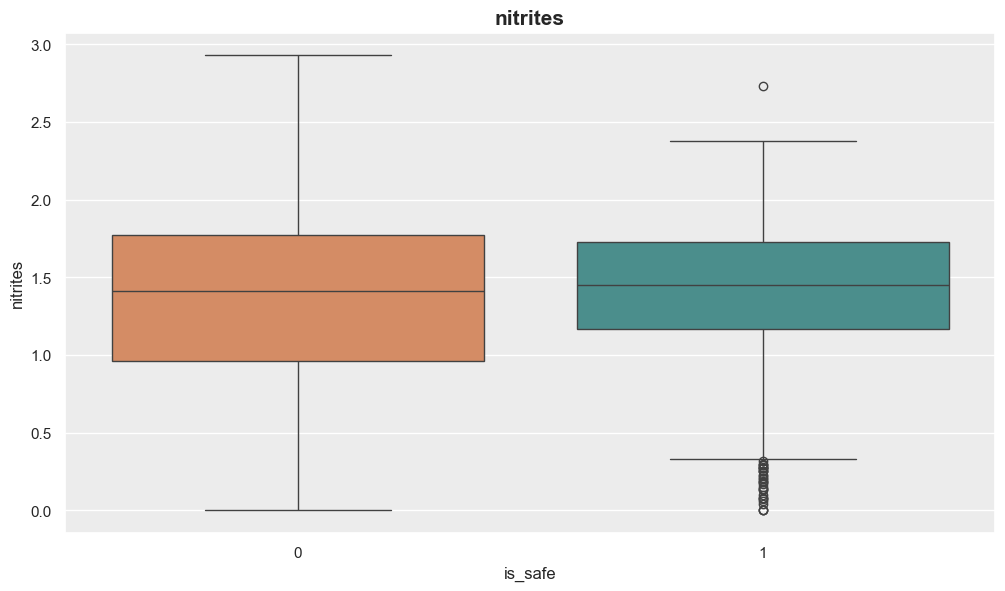

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


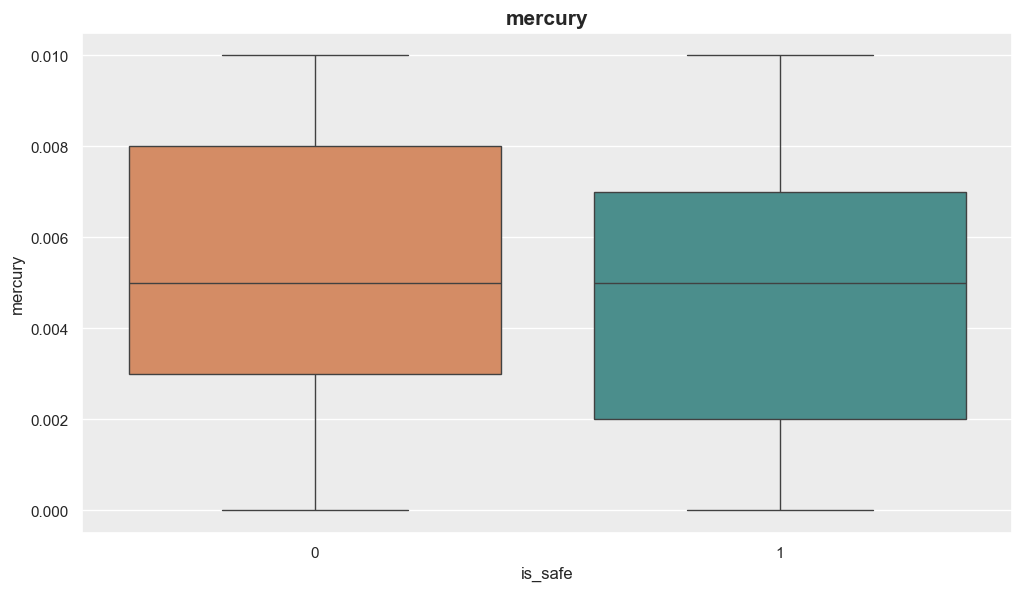

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


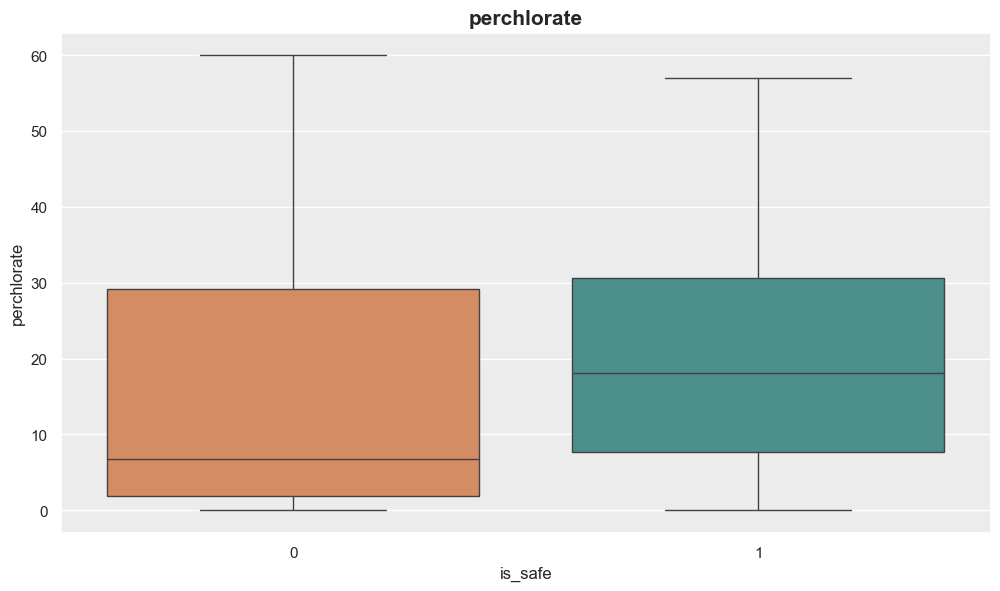

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


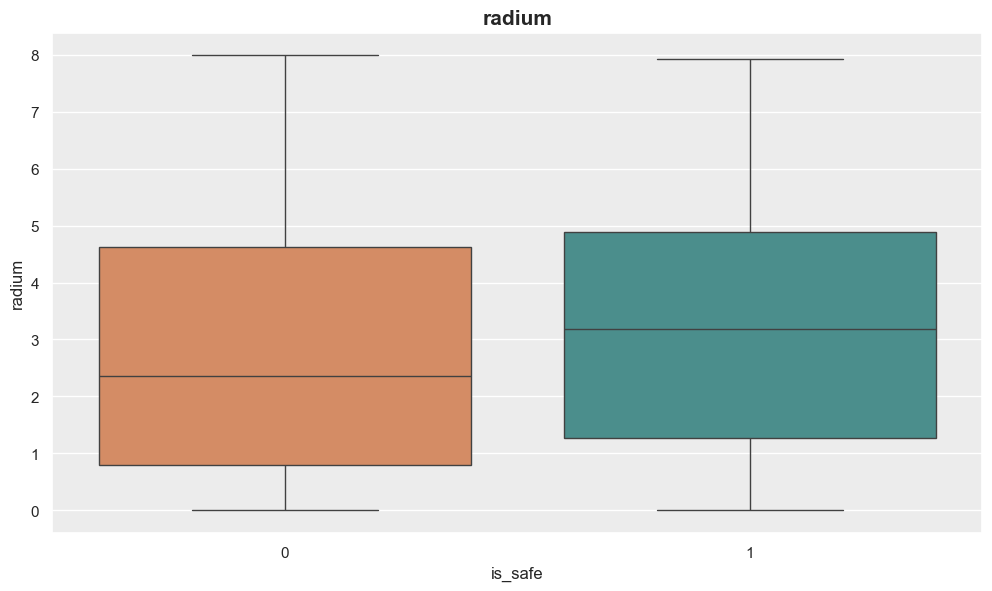

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


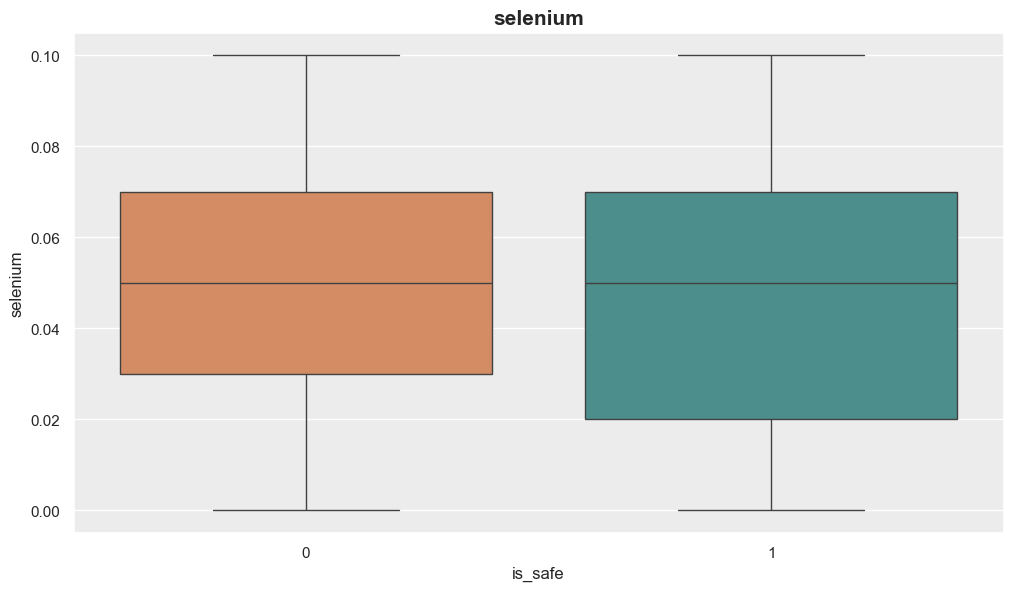

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


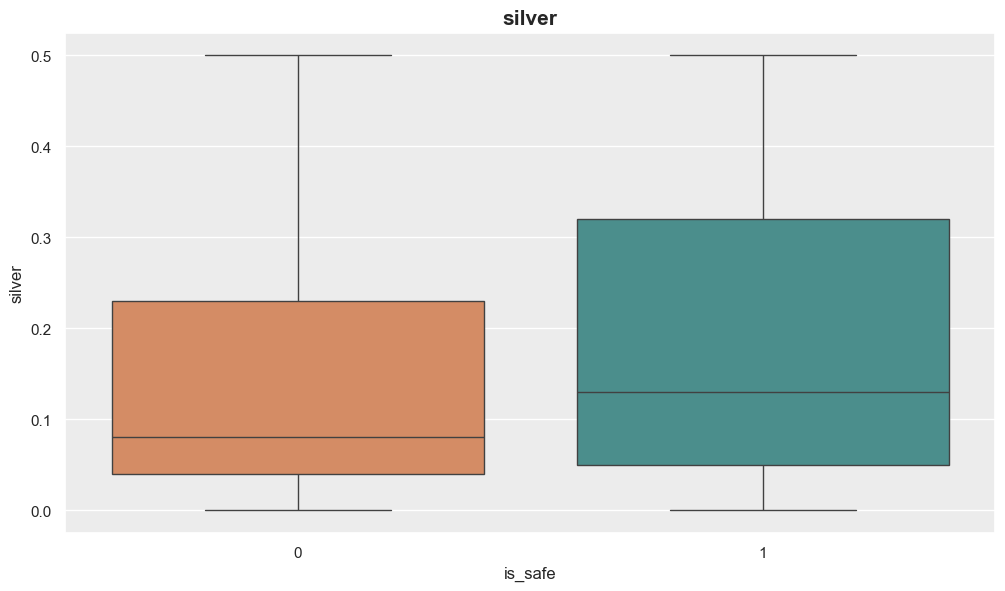

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\3070723930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


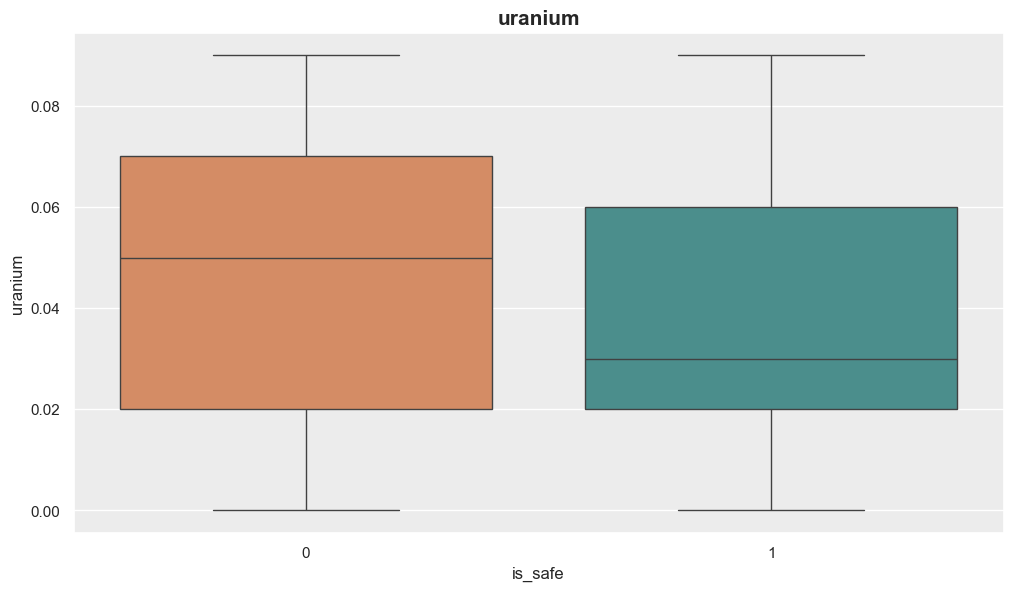

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create list of numeric features
list_of_num_features = data.loc[:, data.columns != 'is_safe'].columns
palette_features = ['#E68753', '#409996']
sns.set_theme(rc={'axes.facecolor':'#ECECEC'})

for feature in list_of_num_features:
    plt.figure(figsize=(12,6.5)) 
    plt.title(feature, fontsize=15, fontweight='bold', fontname='Arial', ha='center')

    sns.boxplot(
        x='is_safe',
        y=feature,
        data=data,
        palette=palette_features
    )

    plt.show()

C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\495323216.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='is_safe', data=data, palette=palette_features)


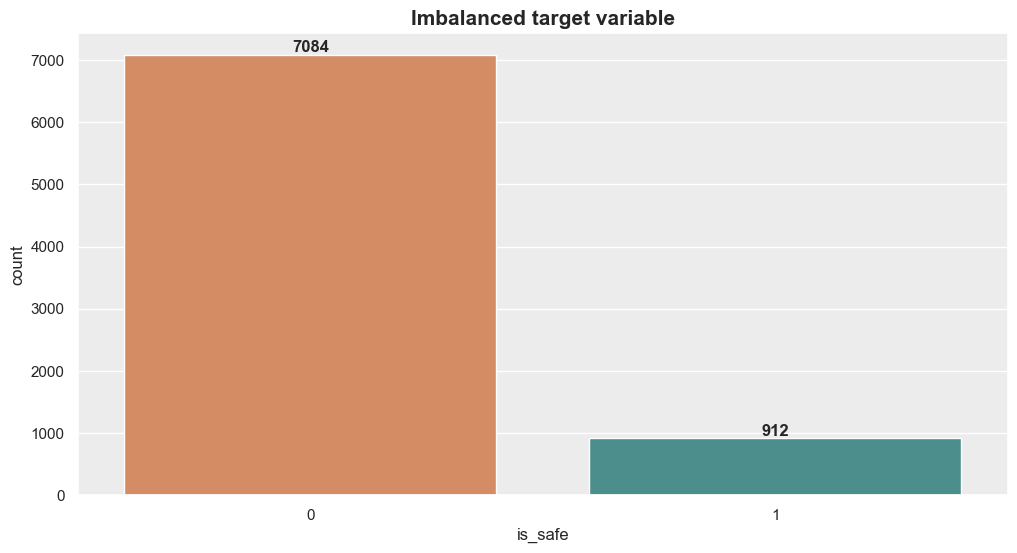

In [54]:
# plot target variable
sns.set_theme(rc={'axes.facecolor': '#ECECEC'})  # background color of plot
plt.figure(figsize=(12, 6))

plt.title("Imbalanced target variable",
          fontsize=15, fontweight='bold', fontname='Arial', ha='center')

ax = sns.countplot(x='is_safe', data=data, palette=palette_features)

# add labels to each bar
abs_values = data['is_safe'].value_counts().sort_index().values

# loop through the bars (patches) and add labels
for bar, label in zip(ax.patches, abs_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # x position
        bar.get_height(),                     # y position
        label,                                # label text
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

plt.show()

📌 As we can see in chart aboce, **the target variable is highly imbalanced** and we'll have to deal with. We will use oversampling strategy using the RandomOverSampler class, thus we will generate same numbers of rows for the value 1 of target variable Is_safe, therefore we will get the same number of rows for both values of target variable. If we would not dealt with the imbalanced target variable, machine learning models would then prefer (would be biased toward) class 0 over 1.❗️

In [55]:
#balance the target variable
columns = data.columns
columns = [c for c in columns if c not in ['is_safe']]
y = data['is_safe'] #prior target variable
X = data[columns]  #prior features

ros = RandomOverSampler(sampling_strategy='minority')
X, y = ros.fit_resample(X, y) #y_train as balanced target variable
print(f"Imbalanced target class: {(y)}\n\nBalanced target class: {Counter(y)}\n")
print(X.shape[0] - data.shape[0], 'new random picked points')

Imbalanced target class: 0        1
1        1
2        0
3        1
4        1
        ..
14163    1
14164    1
14165    1
14166    1
14167    1
Name: is_safe, Length: 14168, dtype: int64

Balanced target class: Counter({1: 7084, 0: 7084})

6172 new random picked points


C:\Users\Rajat\AppData\Local\Temp\ipykernel_35180\2583496774.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y, data=data, palette=palette_features)


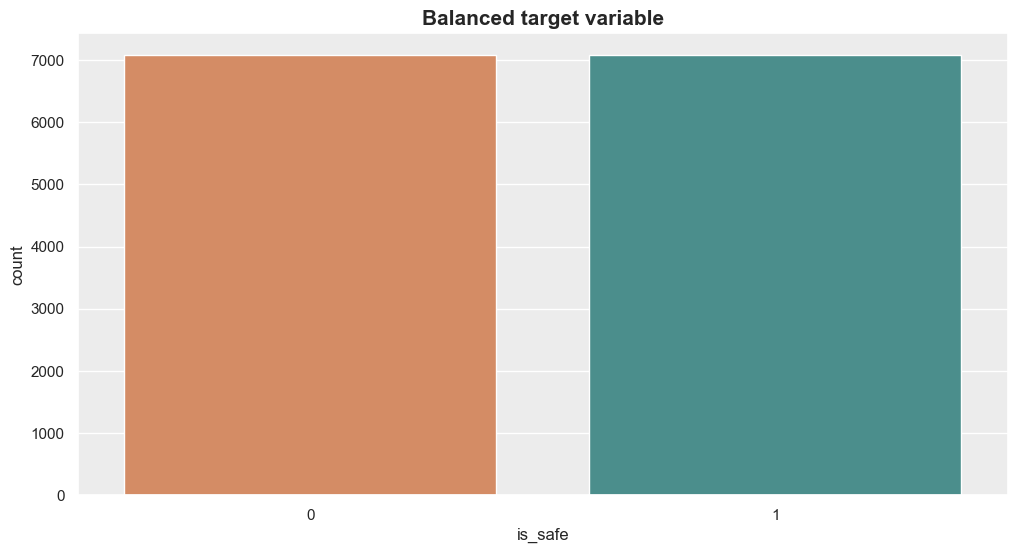

In [56]:
#plot the balanced target variable
sns.set(rc={'axes.facecolor':'#ECECEC'}) #background color of plot
plt.figure(figsize=(12,6))
plt.title("Balanced target variable", fontsize=15, fontweight='bold', fontname='Arial', ha='center')
ax = sns.countplot(x=y, data=data, palette=palette_features)
plt.show()

**2.4 Analyze relationships between variables**

We would also like to check, whether there are any statistically significant (<= -0.70, >= 0.70) correlations between all features. The highest correlations are between Cadmium and Is_safe (-0.26) and also between Viruses and Bateria (0.62). Nevertheless, it is not enough to consider these relations as statistically significant.

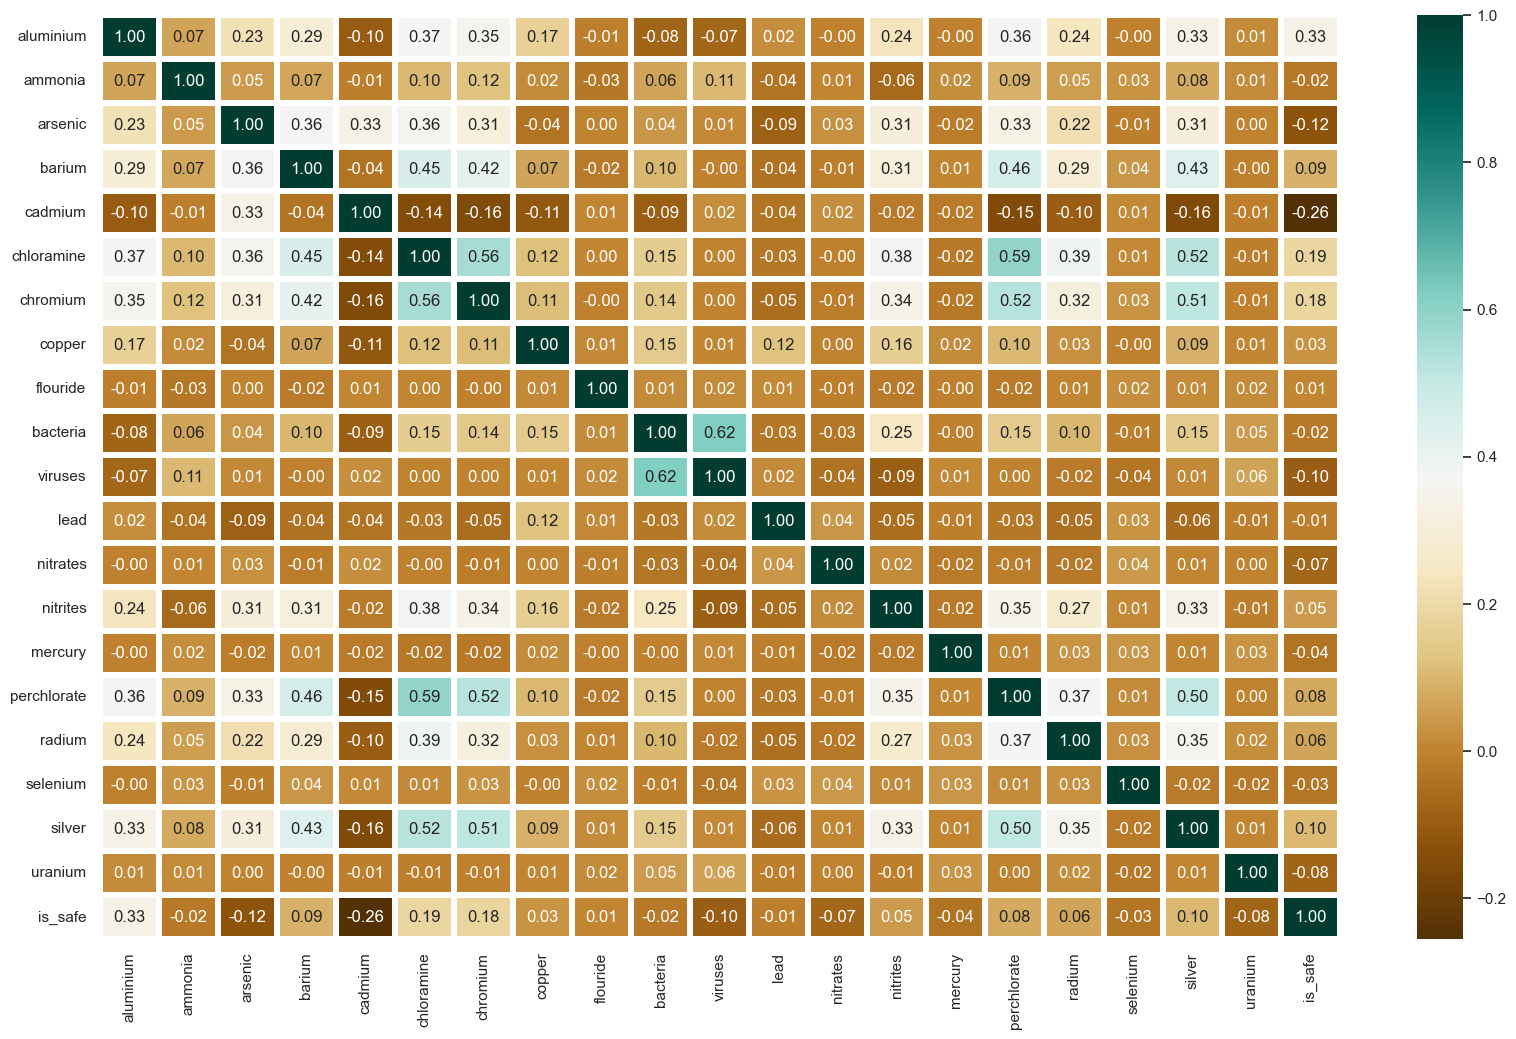

In [57]:
# plotting correlation matrix to notice relationships or lack of it between variables
corr = data.corr()

plt.figure(figsize = (20, 12))
sns.heatmap(corr, xticklabels = corr.columns, yticklabels = corr.columns, linewidths = 4, annot = True, fmt = ".2f", cmap="BrBG")
plt.show()

In [58]:
#preparation of train and test data for K-NN
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) #70 % of train data, 30 % of test data
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9917, 20), (4251, 20), (9917,), (4251,))

[[1512  559]
 [  71 2109]]


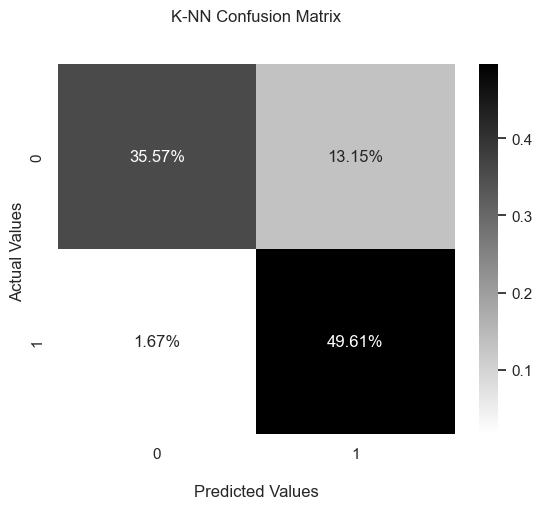

In [59]:
#implement K-NN algorithm
knnc = KNeighborsClassifier()
knnc.fit(X_train, y_train)
y_pred_knnc = knnc.predict(X_test)

#plotting Confusion Matrix
cf_matrix_knnc = confusion_matrix(y_test, y_pred_knnc)
print(cf_matrix_knnc)

ax = sns.heatmap(cf_matrix_knnc/np.sum(cf_matrix_knnc), annot=True, fmt='.2%', cmap='binary')
ax.set_title('K-NN Confusion Matrix\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['0','1'])
ax.yaxis.set_ticklabels(['0','1'])

## Display the visualization of the Confusion Matrix.
plt.show()

In [60]:
#evaluation of K-NN: metrics pivot chart
print(classification_report(y_test, y_pred_knnc))

print('Accuracy Score : ' + str(round(accuracy_score(y_test,y_pred_knnc),3)))
print('Precision Score : ' + str(round(precision_score(y_test,y_pred_knnc),3)))
print('Recall Score : ' + str(round(recall_score(y_test,y_pred_knnc),3)))
print('F-Score : ' + str(round(f1_score(y_test,y_pred_knnc),3)))

              precision    recall  f1-score   support

           0       0.96      0.73      0.83      2071
           1       0.79      0.97      0.87      2180

    accuracy                           0.85      4251
   macro avg       0.87      0.85      0.85      4251
weighted avg       0.87      0.85      0.85      4251

Accuracy Score : 0.852
Precision Score : 0.79
Recall Score : 0.967
F-Score : 0.87


**Preparation of the data for K-NN algorithm**
* ✅ **Numeric Variables**
* ✅ **Address Missing Data**
* **Rescale Data**
* **Reduce Dimensionality**

In [61]:
#preparation of train and test data for ML models
X_train,X_test,y_train,y_test = train_test_split(X, y,test_size=0.3, random_state = 1) #70 % of train data, 30 % of test data
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((9917, 20), (4251, 20), (9917,), (4251,))

In [62]:
# Rescaling the features using standardization
sc = StandardScaler()

sc.fit(X_train)

X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

print('After standardizing our features, the first 5 rows of our data now look like this:\n')
print(pd.DataFrame(X_train_std).head())

After standardizing our features, the first 5 rows of our data now look like this:

         0         1         2         3         4         5         6   \
0 -0.751197 -1.285284 -0.517932 -1.226836 -0.878586  0.500361  0.894812   
1 -0.404854 -0.526706 -0.558263 -0.315437 -0.737358  0.695660  0.434581   
2 -0.065045 -0.779185 -0.383497 -1.210414 -0.737358  1.285387  0.646995   
3  1.006660  0.438652  1.005671  1.573048  1.070358 -0.269347  1.001019   
4  2.398570  0.431797 -0.558263 -0.742398 -0.765603  0.783737  1.284238   

         7         8         9         10        11        12        13  \
0 -0.128388  1.124987  1.703970  1.579795 -0.034058 -1.600629 -0.137612   
1 -0.442013  0.430572 -0.621580 -0.779430  0.556269  1.708423  0.830120   
2 -1.147670  0.199100  0.265801 -0.774001 -1.596689  1.007704  0.888184   
3 -0.473376 -1.513791  1.061384  1.009671 -1.440426 -0.038872  0.984958   
4  1.314288 -1.745263 -0.652179 -0.763141 -1.232075  0.858193  0.694638   

         14   

**Reduce Dimensionality**

For this purpose we will use one of Feature Selection methods. Feature selection is an important concept in ML. It helps to increase prediction power of algorithms by selecting the most critical features to predict the target variable and eliminating redundant ones (dimension reduction).

In [63]:
# find best scored 10 features
select_feature = SelectKBest(f_classif, k=10).fit(X_train, y_train)
print('Score list:', select_feature.scores_)
print('Feature list:', X_train.columns)

Score list: [2.29311504e+03 1.31025092e+01 4.82966571e+02 1.64299671e+02
 2.07740253e+03 9.78050629e+02 7.75231448e+02 1.32117490e+01
 4.06360512e-01 9.35700069e+00 2.30386310e+02 5.45367763e+00
 1.17669809e+02 5.50429871e+01 3.44396390e+01 1.79802584e+02
 1.11501372e+02 3.00561215e+01 2.42409111e+02 1.67120298e+02]
Feature list: Index(['aluminium', 'ammonia', 'arsenic', 'barium', 'cadmium', 'chloramine',
       'chromium', 'copper', 'flouride', 'bacteria', 'viruses', 'lead',
       'nitrates', 'nitrites', 'mercury', 'perchlorate', 'radium', 'selenium',
       'silver', 'uranium'],
      dtype='str')


[[1564  507]
 [  40 2140]]


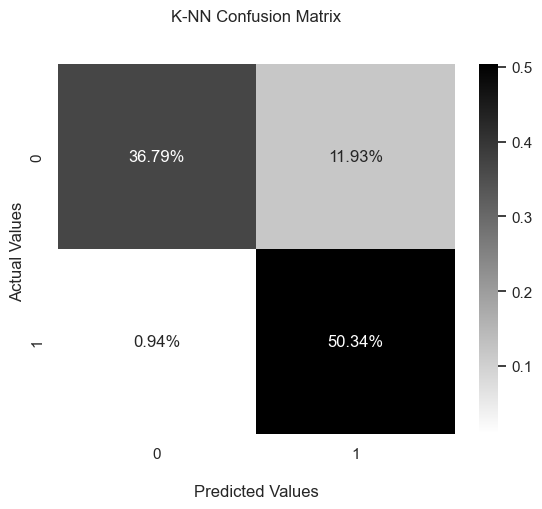

In [64]:
X_train_2 = select_feature.transform(X_train)
X_test_2 = select_feature.transform(X_test)

knnc = KNeighborsClassifier()   
knnc = knnc.fit(X_train_2,y_train)

y_pred_knnc = knnc.predict(X_test_2)

cf_matrix_knnc = confusion_matrix(y_test, y_pred_knnc)
print(cf_matrix_knnc)

ax = sns.heatmap(cf_matrix_knnc/np.sum(cf_matrix_knnc), annot=True, fmt='.2%', cmap='binary')
ax.set_title('K-NN Confusion Matrix\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['0','1'])
ax.yaxis.set_ticklabels(['0','1'])

## Display the visualization of the Confusion Matrix.
plt.show()

In [65]:
#evaluation of K-NN: metrics pivot chart
print(classification_report(y_test, y_pred_knnc))

print('Accuracy Score : ' + str(round(accuracy_score(y_test,y_pred_knnc),3)))
print('Precision Score : ' + str(round(precision_score(y_test,y_pred_knnc,pos_label=0),3)))
print('Recall Score : ' + str(round(recall_score(y_test,y_pred_knnc,pos_label=0),3)))
print('F-Score : ' + str(round(f1_score(y_test,y_pred_knnc,pos_label=0),3)))

              precision    recall  f1-score   support

           0       0.98      0.76      0.85      2071
           1       0.81      0.98      0.89      2180

    accuracy                           0.87      4251
   macro avg       0.89      0.87      0.87      4251
weighted avg       0.89      0.87      0.87      4251

Accuracy Score : 0.871
Precision Score : 0.975
Recall Score : 0.755
F-Score : 0.851


**Hyperparameter tuning of K-NN**

K-NN requires simply only two parameters to be set:
* n_neighbors: number of neighbors (also known as K) which we will use to classify new record. For example, if we set value of n_neighbors = 5, new record will be put into space and its distance to the closest 5 records will be computed. If at least 3 records fall into one category, that category will get this new record.
* metric: metric to compute distance between new sample and its neighbors (Euclidean, Manhattan, Minkowski, Mahalanobis distance)

Best Score:0.9316326883347161
Best Parameters: {'metric': 'euclidean', 'n_neighbors': np.int64(1)}
[[1846  225]
 [   2 2178]]


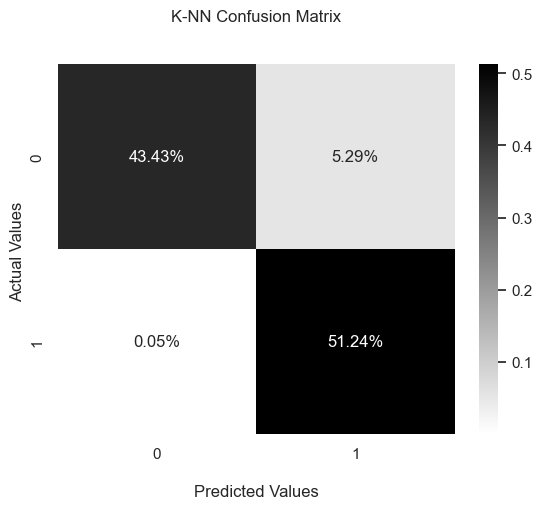

In [66]:
#hyperparameter tuning
param_grid = {'n_neighbors':np.arange(1,40), 'metric':['euclidean', 'manhattan', 'minkowski']}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn,param_grid,cv=5)
knn_cv.fit(X_train_2,y_train)

y_pred_knn_cv = knn_cv.predict(X_test_2)

print("Best Score:" + str(knn_cv.best_score_))
print("Best Parameters: " + str(knn_cv.best_params_))

cf_matrix_knn_cv = confusion_matrix(y_test, y_pred_knn_cv)
print(cf_matrix_knn_cv)

ax = sns.heatmap(cf_matrix_knn_cv/np.sum(cf_matrix_knn_cv), annot=True, fmt='.2%', cmap='binary')
ax.set_title('K-NN Confusion Matrix\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['0','1'])
ax.yaxis.set_ticklabels(['0','1'])

## Display the visualization of the Confusion Matrix.
plt.show()


In [67]:
#evaluation of K-NN: metrics pivot chart
print(classification_report(y_test, y_pred_knn_cv))

print('Accuracy Score : ' + str(round(accuracy_score(y_test,y_pred_knn_cv),3)))
print('Precision Score : ' + str(round(precision_score(y_test,y_pred_knn_cv,pos_label=0),3)))
print('Recall Score : ' + str(round(recall_score(y_test,y_pred_knn_cv,pos_label=0),3)))
print('F-Score : ' + str(round(f1_score(y_test,y_pred_knn_cv,pos_label=0),3)))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94      2071
           1       0.91      1.00      0.95      2180

    accuracy                           0.95      4251
   macro avg       0.95      0.95      0.95      4251
weighted avg       0.95      0.95      0.95      4251

Accuracy Score : 0.947
Precision Score : 0.999
Recall Score : 0.891
F-Score : 0.942


In our case, precision metric is much more important than recall metric. It is better to classify potable water as non-potable (FN)  and perform further tests than classify non-potable water as potable (FP), which could lead to unwanted poisoning.

In [68]:
# create numpy array for future K value
neighbors = np.arange(1, 40)
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

In [69]:
# Loop over different values of k
for i, k in enumerate(neighbors):
    # Setup a k-NN Classifier with k neighbors: knn
    knn = KNeighborsClassifier(n_neighbors=k)

    # Fit the classifier to the training data
    knn.fit(X_train_2, y_train)
    
    #Compute accuracy on the training set
    train_accuracy[i] = knn.score(X_train_2, y_train)

    #Compute accuracy on the testing set
    test_accuracy[i] = knn.score(X_test_2, y_test)

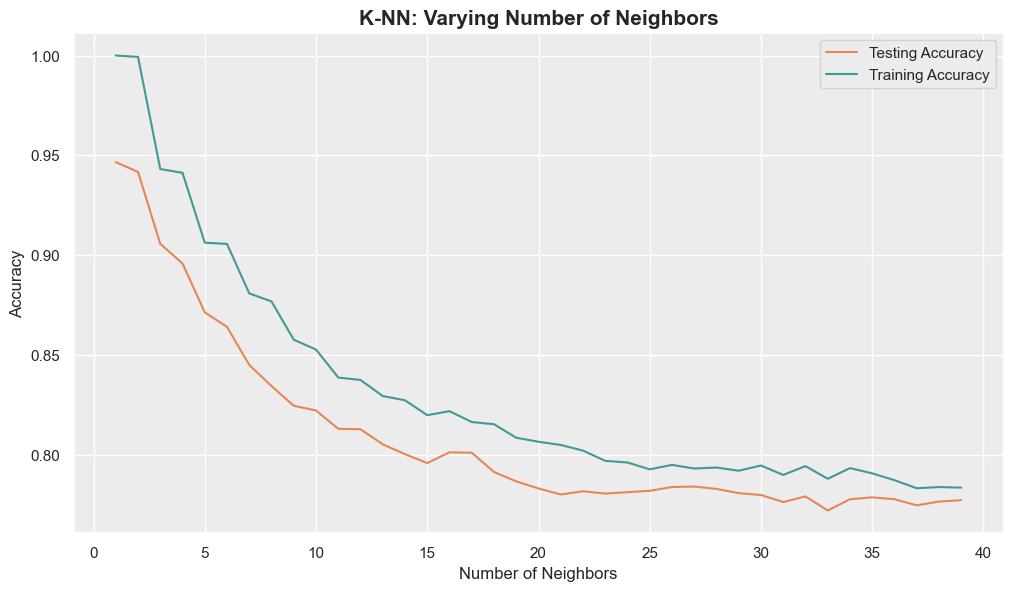

In [70]:
# Generate plot
sns.set_theme(rc={'axes.facecolor':'#ECECEC'}) #background color of all plots
plt.figure(figsize=(12,6.5)) 
plt.title(label='K-NN: Varying Number of Neighbors', fontsize=15, fontweight='bold', fontname='Arial', ha='center')
plt.plot(neighbors, test_accuracy, label = 'Testing Accuracy', color='#E68753')
plt.plot(neighbors, train_accuracy, label = 'Training Accuracy', color = '#409996')
plt.legend()
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.show()